In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")
import joblib
import time
from torch.utils.tensorboard import SummaryWriter
import cv2
from torchvision import transforms
from PIL import Image
import glob
import random

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
print("Version Information:")
print(f"PyTorch: {torch.__version__}")
print(f" torchvision: {torchvision.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print("Library versions printed successfully.")

Version Information:
PyTorch: 2.8.0+cpu
 torchvision: 0.23.0+cpu
NumPy: 2.2.1
Pandas: 2.2.3
Matplotlib: 3.10.0
Seaborn: 0.13.2
Library versions printed successfully.


# Test Images

In [4]:
# ============================================================
# LSUI Dataset Visualization for Underwater Image Enhancement
# ============================================================

# Assuming your dataset is organized as:
#   LSUI/train/input/   -> degraded underwater images
#   LSUI/train/GT/      -> ground truth enhanced images
#   LSUI/test/input/
#   LSUI/test/GT/

# --- Configuration: Update these paths for your system ---
DATASET_PATH = "./LSUI"          # Root path to LSUI dataset
SPLIT = "test"                  # "train" or "test"

# ------------------------------------------------------------

# Build paths
input_dir = os.path.join(DATASET_PATH, SPLIT, "input")
gt_dir = os.path.join(DATASET_PATH, SPLIT, "GT")

# Get list of image files
input_images = sorted(glob.glob(os.path.join(input_dir, "*")))
gt_images = sorted(glob.glob(os.path.join(gt_dir, "*")))

print(f"Found {len(input_images)} input images in '{input_dir}'")
print(f"Found {len(gt_images)} GT images in '{gt_dir}'")

# Display some sample filenames
print("\n--- Sample Input Filenames ---")
for f in input_images[:5]:
    print(f"  {os.path.basename(f)}")

print("\n--- Sample GT Filenames ---")
for f in gt_images[:5]:
    print(f"  {os.path.basename(f)}")

Found 108 input images in './LSUI\test\input'
Found 108 GT images in './LSUI\test\GT'

--- Sample Input Filenames ---
  100.jpg
  101.jpg
  103.jpg
  104.jpg
  25.jpg

--- Sample GT Filenames ---
  100.jpg
  101.jpg
  103.jpg
  104.jpg
  25.jpg


# 1. Display Side-by-Side Comparisons
## This shows input vs. ground truth images in a grid:

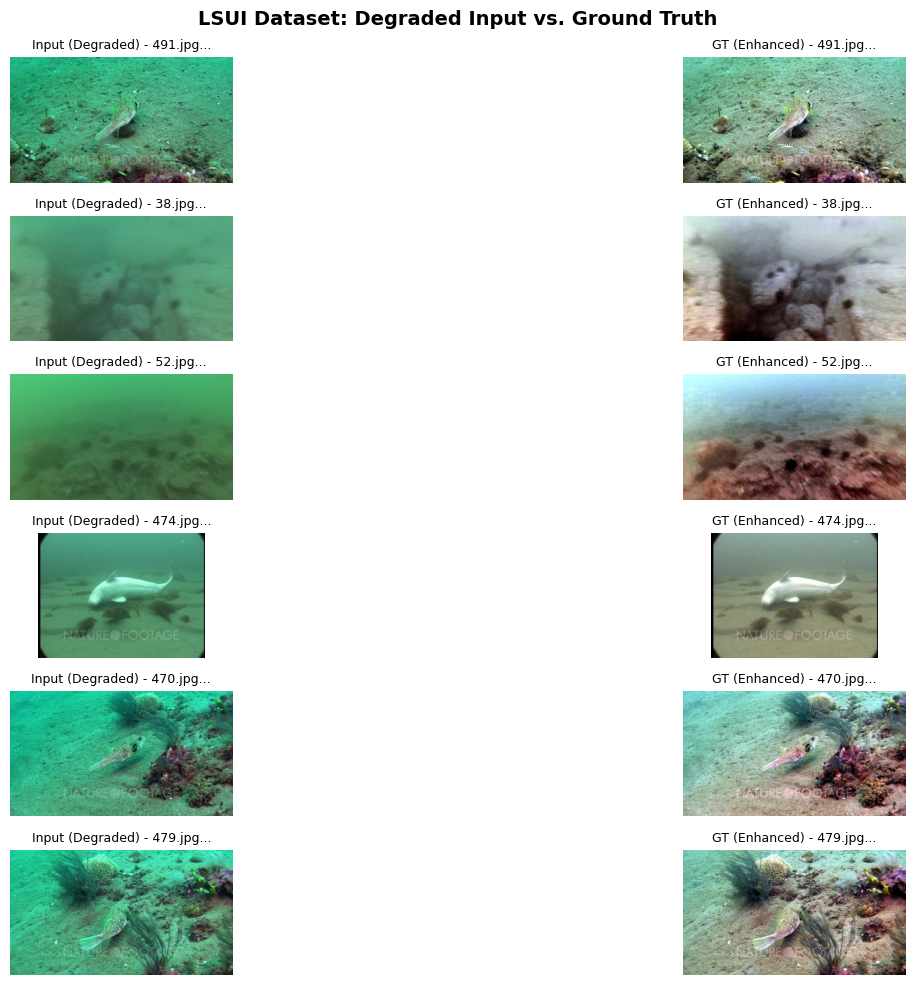

In [5]:
def show_paired_images(input_dir, gt_dir, num_pairs=6, figsize=(18, 10)):
    """
    Display side-by-side comparison of degraded input images
    and their corresponding ground truth enhanced images.
    """
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    
    # Ensure we only use matching files
    common_files = list(set(input_files) & set(gt_files))
    selected = random.sample(common_files, min(num_pairs, len(common_files)))
    
    fig, axes = plt.subplots(num_pairs, 2, figsize=figsize)
    
    for i, fname in enumerate(selected):
        # Read input (degraded) image
        inp_path = os.path.join(input_dir, fname)
        gt_path = os.path.join(gt_dir, fname)
        
        inp_img = cv2.imread(inp_path)
        gt_img = cv2.imread(gt_path)
        
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        inp_img = cv2.cvtColor(inp_img, cv2.COLOR_BGR2RGB)
        gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
        
        # Plot
        axes[i, 0].imshow(inp_img)
        axes[i, 0].set_title(f"Input (Degraded) - {fname[:30]}...", fontsize=9)
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(gt_img)
        axes[i, 1].set_title(f"GT (Enhanced) - {fname[:30]}...", fontsize=9)
        axes[i, 1].axis("off")
    
    fig.suptitle("LSUI Dataset: Degraded Input vs. Ground Truth", 
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Usage
show_paired_images(input_dir, gt_dir, num_pairs=6)

# 2. Statistical Overview of the Dataset

In [6]:
def dataset_statistics(input_dir, gt_dir):
    """Display statistics about the dataset."""
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    
    print("=" * 50)
    print("LSUI DATASET STATISTICS")
    print("=" * 50)
    print(f"Total input images:  {len(input_files)}")
    print(f"Total GT images:     {len(gt_files)}")
    print(f"Common pairs:        {len(set(input_files) & set(gt_files))}")
    
    # Sample a few images for size and aspect ratio analysis
    sample_files = random.sample(input_files, min(50, len(input_files)))
    heights, widths = [], []
    
    for f in sample_files:
        img = cv2.imread(os.path.join(input_dir, f))
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)
    
    if heights:
        print(f"\nImage dimensions (sample of {len(heights)}):")
        print(f"  Height: min={min(heights)}, max={max(heights)}, "
              f"mean={np.mean(heights):.1f}")
        print(f"  Width:  min={min(widths)}, max={max(widths)}, "
              f"mean={np.mean(widths):.1f}")
        print(f"  Aspect ratio (W/H): mean={np.mean(np.array(widths)/np.array(heights)):.2f}")
    
    # Pixel intensity distribution of a sample image
    sample_img = cv2.imread(os.path.join(input_dir, sample_files[0]))
    if sample_img is not None:
        print(f"\nSample image pixel stats (BGR):")
        for i, channel in enumerate(['B', 'G', 'R']):
            print(f"  {channel}: mean={sample_img[:,:,i].mean():.1f}, "
                  f"std={sample_img[:,:,i].std():.1f}, "
                  f"min={sample_img[:,:,i].min()}, max={sample_img[:,:,i].max()}")

dataset_statistics(input_dir, gt_dir)

LSUI DATASET STATISTICS
Total input images:  108
Total GT images:     108
Common pairs:        108

Image dimensions (sample of 50):
  Height: min=360, max=778, mean=393.6
  Width:  min=480, max=1037, mean=689.5
  Aspect ratio (W/H): mean=1.76

Sample image pixel stats (BGR):
  B: mean=63.8, std=25.4, min=14, max=162
  G: mean=88.2, std=35.3, min=23, max=223
  R: mean=59.3, std=22.8, min=13, max=145


# 3. Colour Channel Analysis
This helps you understand the colour bias in underwater images (typically blue-green dominant):

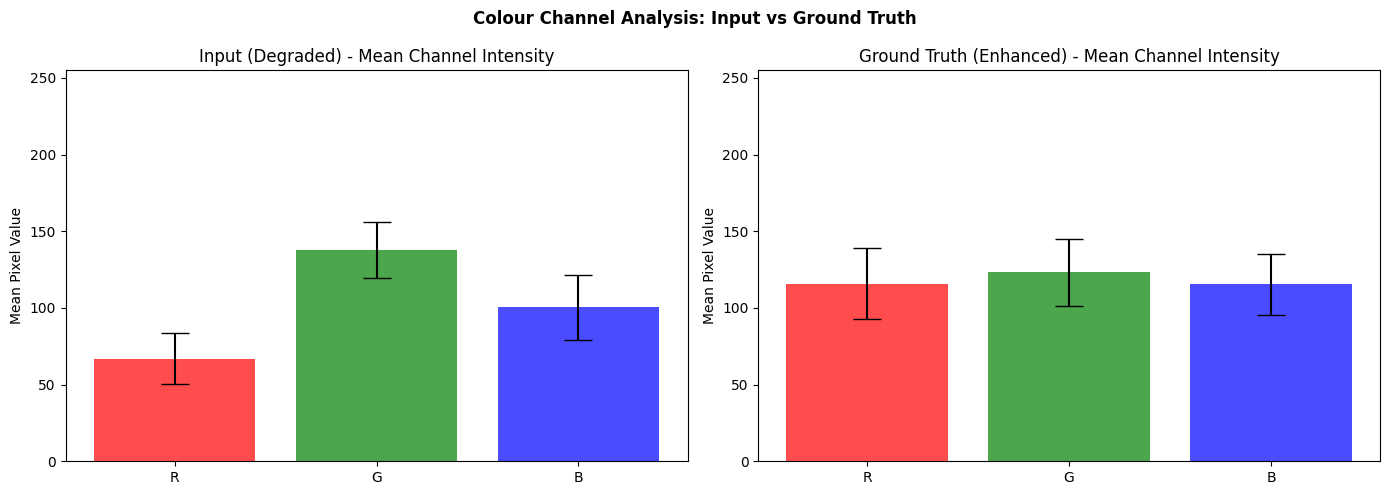

In [7]:
def channel_histogram_analysis(input_dir, gt_dir, num_samples=20):
    """Plot per-channel histograms for input vs GT images."""
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    common = list(set(input_files) & set(gt_files))
    samples = random.sample(common, min(num_samples, len(common)))
    
    inp_means = {'R': [], 'G': [], 'B': []}
    gt_means = {'R': [], 'G': [], 'B': []}
    
    for f in samples:
        inp = cv2.imread(os.path.join(input_dir, f))
        gt = cv2.imread(os.path.join(gt_dir, f))
        if inp is None or gt is None:
            continue
        
        # BGR order in OpenCV: 0=Blue, 1=Green, 2=Red
        for i, ch in enumerate(['B', 'G', 'R']):
            inp_means[ch].append(inp[:,:,i].mean())
            gt_means[ch].append(gt[:,:,i].mean())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, data, title in zip(axes, [inp_means, gt_means], 
                                ["Input (Degraded)", "Ground Truth (Enhanced)"]):
        ax.bar(['R', 'G', 'B'], 
               [np.mean(data['R']), np.mean(data['G']), np.mean(data['B'])],
               yerr=[np.std(data['R']), np.std(data['G']), np.std(data['B'])],
               color=['red', 'green', 'blue'], alpha=0.7, capsize=10)
        ax.set_title(f"{title} - Mean Channel Intensity")
        ax.set_ylabel("Mean Pixel Value")
        ax.set_ylim(0, 255)
    
    fig.suptitle("Colour Channel Analysis: Input vs Ground Truth", fontweight="bold")
    plt.tight_layout()
    plt.show()

channel_histogram_analysis(input_dir, gt_dir, num_samples=30)

# 4. Degradation Type Breakdown

Underwater images typically fall into three categories — blue-ish, green-ish, and well-lit scenes. Here's a simple heuristic to classify them:

In [8]:
def classify_degradation_type(input_dir, num_samples=50):
    """
    Classify images into blue-ish, green-ish, and well-lit based on
    the dominant colour channel.
    """
    input_files = sorted(os.listdir(input_dir))
    samples = random.sample(input_files, min(num_samples, len(input_files)))
    
    blue_count, green_count, well_lit = 0, 0, 0
    
    for f in samples:
        img = cv2.imread(os.path.join(input_dir, f))
        if img is None:
            continue
        b_mean = img[:,:,0].mean()
        g_mean = img[:,:,1].mean()
        r_mean = img[:,:,2].mean()
        
        if b_mean > g_mean and b_mean > r_mean:
            blue_count += 1
        elif g_mean > b_mean and g_mean > r_mean:
            green_count += 1
        else:
            well_lit += 1
    
    print("Degradation Type Distribution:")
    print(f"  Blue-ish (deep water):  {blue_count} ({100*blue_count/len(samples):.1f}%)")
    print(f"  Green-ish (algae-rich): {green_count} ({100*green_count/len(samples):.1f}%)")
    print(f"  Well-lit (shallow):     {well_lit} ({100*well_lit/len(samples):.1f}%)")

classify_degradation_type(input_dir, num_samples=100)

Degradation Type Distribution:
  Blue-ish (deep water):  7 (7.0%)
  Green-ish (algae-rich): 92 (92.0%)
  Well-lit (shallow):     1 (1.0%)


# 5. Quick Sanity Check: Verify Paired Images

Ensure every input image has a corresponding GT image:

In [9]:
def verify_pairs(input_dir, gt_dir):
    """Check for mismatches between input and GT directories."""
    input_files = set(os.listdir(input_dir))
    gt_files = set(os.listdir(gt_dir))
    
    only_in_input = input_files - gt_files
    only_in_gt = gt_files - input_files
    common = input_files & gt_files
    
    print(f"Files only in input:  {len(only_in_input)}")
    print(f"Files only in GT:     {len(only_in_gt)}")
    print(f"Matched pairs:        {len(common)}")
    
    if only_in_input:
        print("\n⚠️  WARNING: Some input images have no GT counterpart!")
        for f in list(only_in_input)[:5]:
            print(f"  - {f}")
    if only_in_gt:
        print("\n⚠️  WARNING: Some GT images have no input counterpart!")
        for f in list(only_in_gt)[:5]:
            print(f"  - {f}")
    if not only_in_input and not only_in_gt:
        print("\n✅ All images are perfectly paired!")

verify_pairs(input_dir, gt_dir)

Files only in input:  0
Files only in GT:     0
Matched pairs:        108

✅ All images are perfectly paired!


# Pixel Intensity Distribution (Histogram Overlay)

See how the overall pixel distribution shifts between input and ground truth:

  Processed 10/100 images
  Processed 20/100 images
  Processed 30/100 images
  Processed 40/100 images
  Processed 50/100 images
  Processed 60/100 images
  Processed 70/100 images
  Processed 80/100 images
  Processed 90/100 images
  Processed 100/100 images


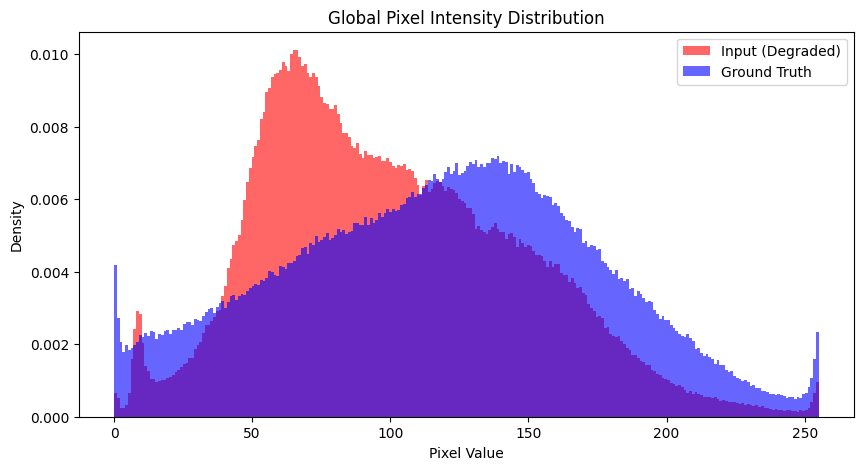

In [19]:
def pixel_intensity_histogram(input_dir, gt_dir, num_samples=100, resize_to=(128,128)):
    import random, cv2, numpy as np, matplotlib.pyplot as plt
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    common = list(set(input_files) & set(gt_files))
    samples = random.sample(common, min(num_samples, len(common)))

    inp_pix = []
    gt_pix = []

    for i, f in enumerate(samples):
        inp = cv2.imread(os.path.join(input_dir, f))
        gt = cv2.imread(os.path.join(gt_dir, f))
        if inp is None or gt is None:
            continue

        # Resize to reduce pixel count
        inp = cv2.resize(inp, resize_to)
        gt = cv2.resize(gt, resize_to)

        # Take every 2nd pixel (still representative)
        inp_pix.extend(inp[::2, ::2].flatten())
        gt_pix.extend(gt[::2, ::2].flatten())

        if (i+1) % 10 == 0:
            print(f"  Processed {i+1}/{len(samples)} images")

    plt.figure(figsize=(10,5))
    plt.hist(inp_pix, bins=256, alpha=0.6, label='Input (Degraded)', color='red', density=True)
    plt.hist(gt_pix, bins=256, alpha=0.6, label='Ground Truth', color='blue', density=True)
    plt.title('Global Pixel Intensity Distribution')
    plt.xlabel('Pixel Value')
    plt.ylabel('Density')
    plt.legend()
    plt.show()


pixel_intensity_histogram(input_dir, gt_dir)

# Sharpness / Blurriness (Laplacian Variance)

Underwater images are often blurred. Compare sharpness between input and GT:

  Processed 20/108 images
  Processed 40/108 images
  Processed 60/108 images
  Processed 80/108 images
  Processed 100/108 images


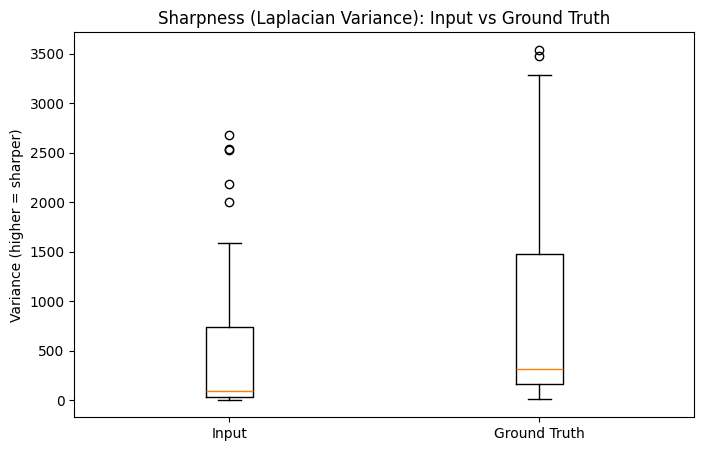

In [20]:
def sharpness_comparison(input_dir, gt_dir, num_samples=500, resize_to=(256,256)):
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    common = list(set(input_files) & set(gt_files))
    samples = random.sample(common, min(num_samples, len(common)))

    inp_sharpness = []
    gt_sharpness = []

    for i, f in enumerate(samples):
        inp = cv2.imread(os.path.join(input_dir, f), cv2.IMREAD_GRAYSCALE)
        gt = cv2.imread(os.path.join(gt_dir, f), cv2.IMREAD_GRAYSCALE)
        if inp is None or gt is None:
            continue

        # Resize to a consistent size to speed up Laplacian
        inp = cv2.resize(inp, resize_to, interpolation=cv2.INTER_AREA)
        gt  = cv2.resize(gt, resize_to, interpolation=cv2.INTER_AREA)

        inp_sharpness.append(cv2.Laplacian(inp, cv2.CV_64F).var())
        gt_sharpness.append(cv2.Laplacian(gt, cv2.CV_64F).var())

        if (i+1) % 20 == 0:
            print(f"  Processed {i+1}/{len(samples)} images")

    plt.figure(figsize=(8,5))
    plt.boxplot([inp_sharpness, gt_sharpness], labels=['Input', 'Ground Truth'])
    plt.title('Sharpness (Laplacian Variance): Input vs Ground Truth')
    plt.ylabel('Variance (higher = sharper)')
    plt.show()


sharpness_comparison(input_dir, gt_dir)

# Colour Cast Severity – Blue/Green Channel Dominance

Quantify how severe the colour cast is:

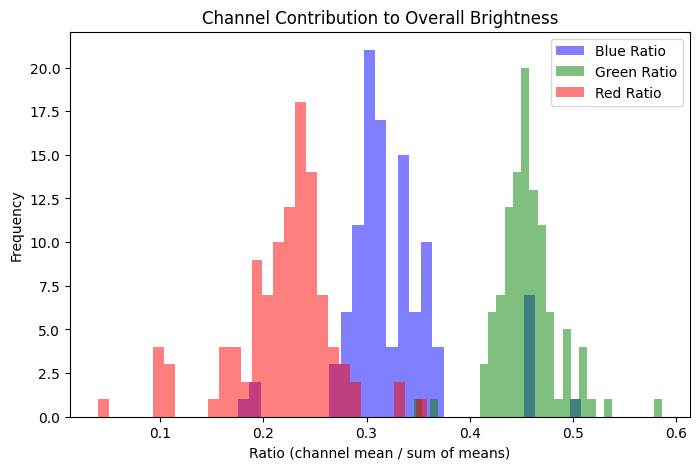

In [24]:
def colour_cast_analysis(input_dir, num_samples=100):
    input_files = sorted(os.listdir(input_dir))
    samples = random.sample(input_files, min(num_samples, len(input_files)))

    blue_ratios, green_ratios, red_ratios = [], [], []

    for f in samples:
        img = cv2.imread(os.path.join(input_dir, f))
        if img is None:
            continue
        b, g, r = img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()
        total = b + g + r
        blue_ratios.append(b / total)
        green_ratios.append(g / total)
        red_ratios.append(r / total)

    plt.figure(figsize=(8, 5))
    plt.hist(blue_ratios, bins=30, alpha=0.5, label='Blue Ratio', color='blue')
    plt.hist(green_ratios, bins=30, alpha=0.5, label='Green Ratio', color='green')
    plt.hist(red_ratios, bins=30, alpha=0.5, label='Red Ratio', color='red')
    plt.title('Channel Contribution to Overall Brightness')
    plt.xlabel('Ratio (channel mean / sum of means)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


colour_cast_analysis(input_dir, num_samples=500)

# Image Quality Metrics (UIQM, UCIQE) Distribution

These no‑reference metrics help you understand the baseline quality of your input images.

Define the metrics (simplified versions from the literature):

In [ ]:
def calculate_uciqe(img_bgr):
    """Simplified UCIQE: chroma std, luminance contrast, saturation mean."""
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel = img[:,:,0]
    a_channel = img[:,:,1]
    b_channel = img[:,:,2]

    chroma = np.sqrt(a_channel.astype(float)**2 + b_channel.astype(float)**2)
    sigma_c = np.std(chroma)
    con_l = np.std(l_channel)  # luminance contrast approximation
    mu_s = np.mean(chroma)     # saturation mean
    uciqe = 0.4680 * sigma_c + 0.2745 * con_l + 0.2576 * mu_s
    return uciqe

def calculate_uiqm(img_bgr):
    """Simplified UIQM: colourfulness, sharpness, contrast."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Colourfulness (UICM) - simplified from Panetta et al.
    rg = np.abs(img_rgb[:,:,0].astype(float) - img_rgb[:,:,1].astype(float))
    yb = np.abs(0.5 * (img_rgb[:,:,0].astype(float) + img_rgb[:,:,1].astype(float)) - img_rgb[:,:,2].astype(float))
    uicm = (np.std(rg) + np.std(yb)) / 2.0

    # Sharpness (UISM) - Laplacian based
    uism = cv2.Laplacian(img_gray, cv2.CV_64F).var()

    # Contrast (UIConM)
    uiconm = np.std(img_gray) / 128.0  # rough normalization

    uiqm = 0.028 * uicm + 0.295 * uism + 3.575 * uiconm  # weights from literature
    return uiqm




Now plot the distributions:

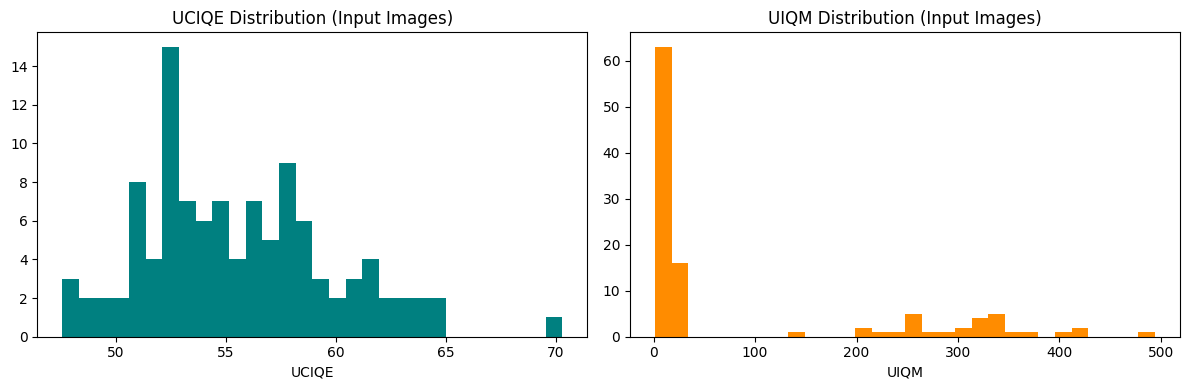

In [26]:
def quality_metric_distribution(input_dir, num_samples=200):
    input_files = sorted(os.listdir(input_dir))
    samples = random.sample(input_files, min(num_samples, len(input_files)))

    uciqe_scores, uiqm_scores = [], []

    for f in samples:
        img = cv2.imread(os.path.join(input_dir, f))
        if img is None:
            continue
        uciqe_scores.append(calculate_uciqe(img))
        uiqm_scores.append(calculate_uiqm(img))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(uciqe_scores, bins=30, color='teal')
    axes[0].set_title('UCIQE Distribution (Input Images)')
    axes[0].set_xlabel('UCIQE')
    axes[1].hist(uiqm_scores, bins=30, color='darkorange')
    axes[1].set_title('UIQM Distribution (Input Images)')
    axes[1].set_xlabel('UIQM')
    plt.tight_layout()
    plt.show()


quality_metric_distribution(input_dir, num_samples=200)

# Unique Colour Content: Hue-Saturation Histogram

See the colour distribution shift in HSV space:

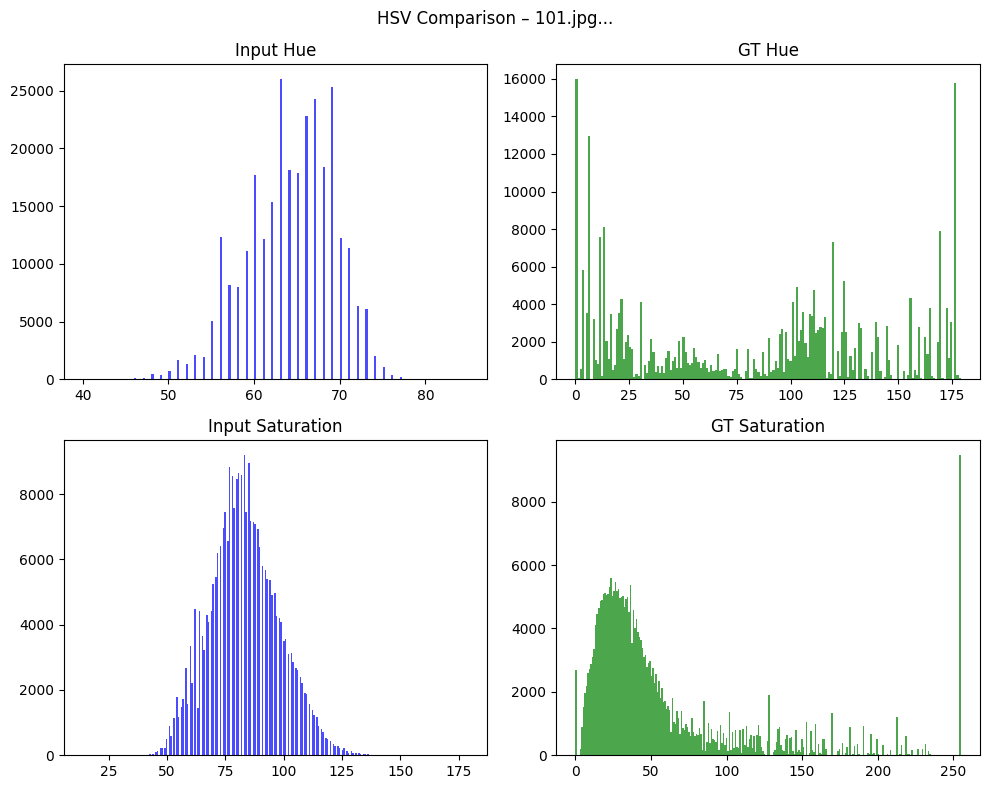

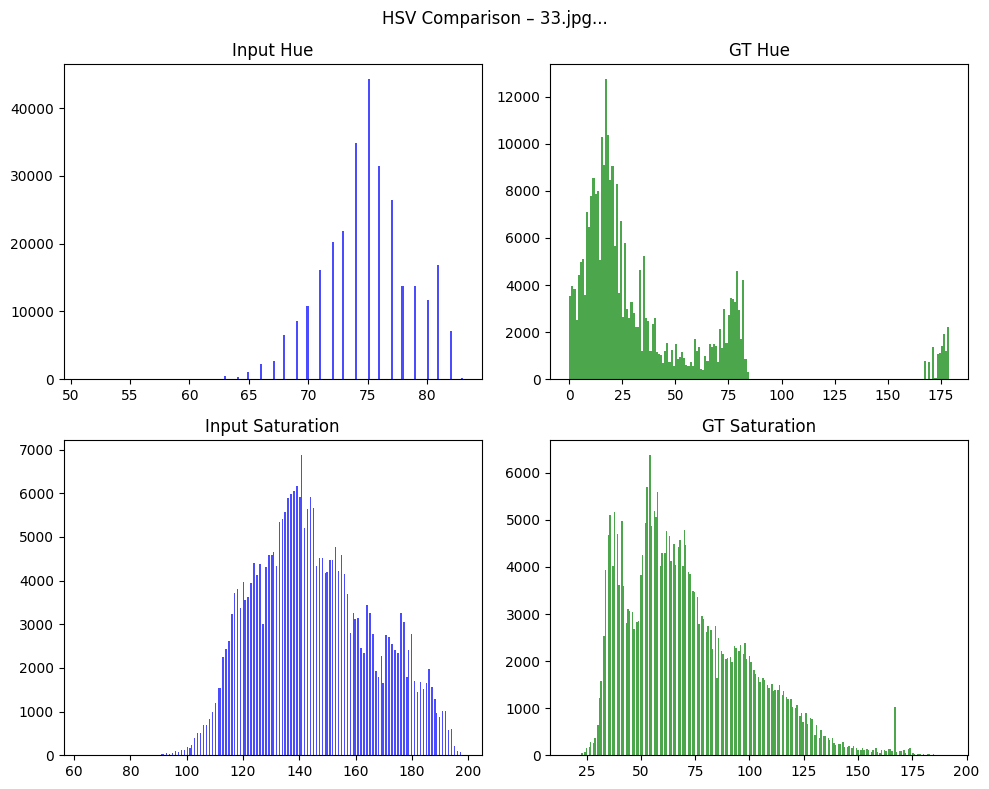

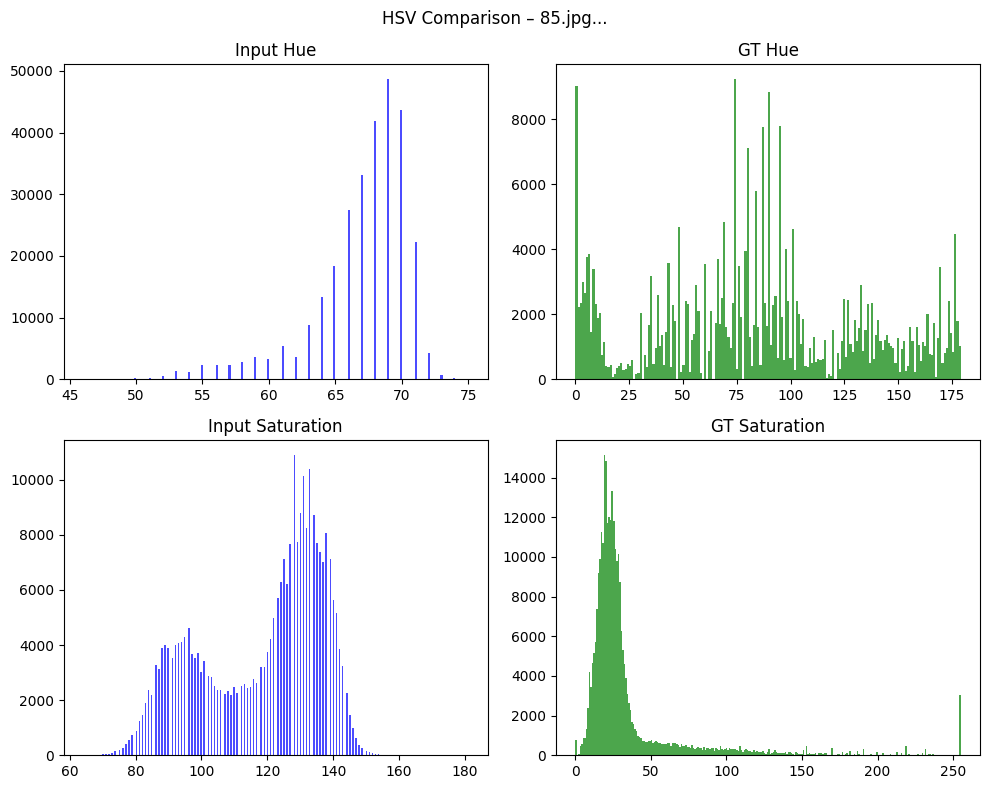

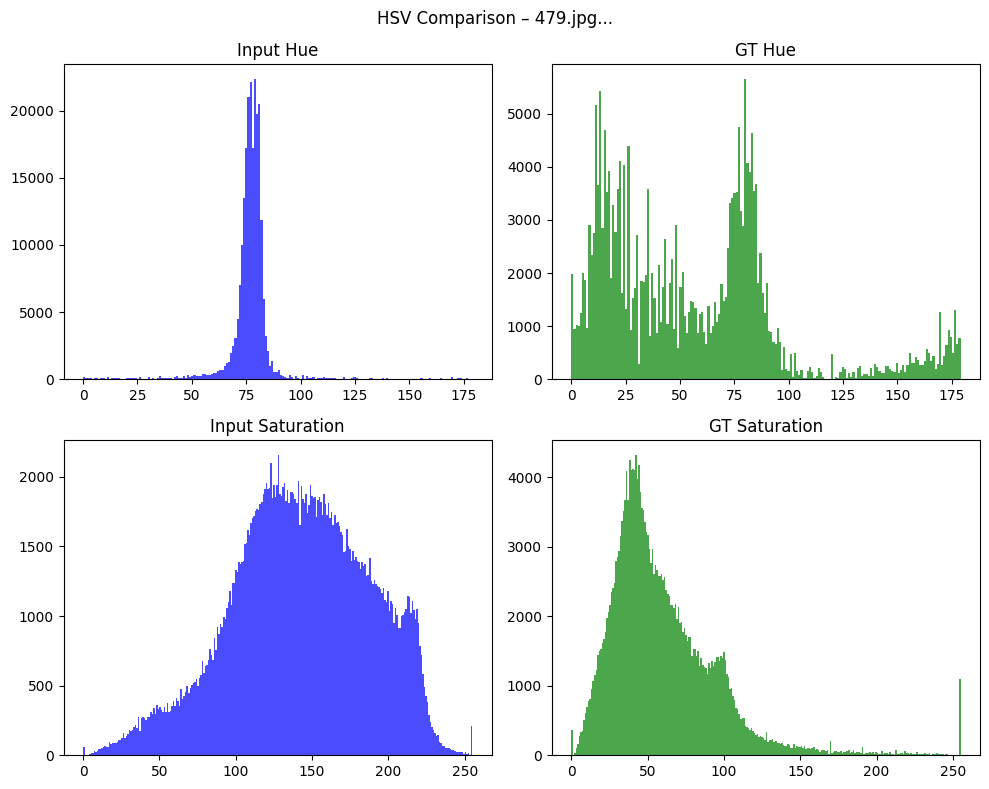

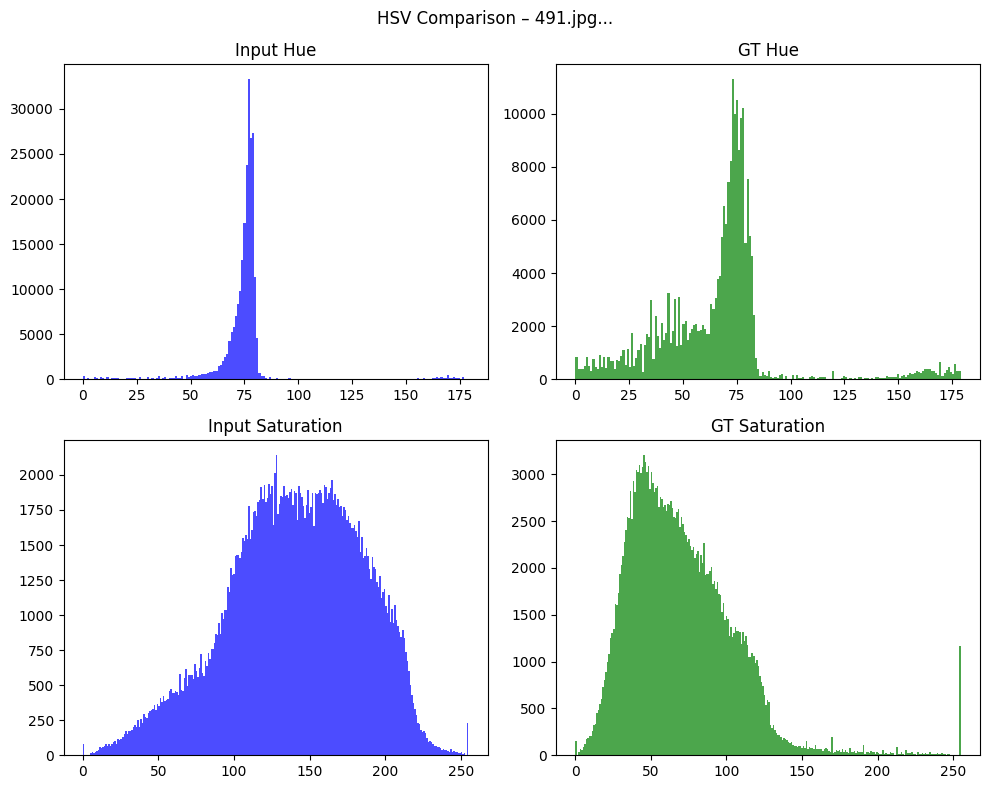

In [28]:
def hsv_comparison(input_dir, gt_dir, num_pairs=5):
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    common = list(set(input_files) & set(gt_files))
    samples = random.sample(common, min(num_pairs, len(common)))

    for idx, f in enumerate(samples):
        inp = cv2.imread(os.path.join(input_dir, f))
        gt = cv2.imread(os.path.join(gt_dir, f))
        if inp is None or gt is None:
            continue

        inp_hsv = cv2.cvtColor(inp, cv2.COLOR_BGR2HSV)
        gt_hsv = cv2.cvtColor(gt, cv2.COLOR_BGR2HSV)

        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes[0,0].hist(inp_hsv[:,:,0].flatten(), bins=180, color='blue', alpha=0.7)
        axes[0,0].set_title('Input Hue')
        axes[0,1].hist(gt_hsv[:,:,0].flatten(), bins=180, color='green', alpha=0.7)
        axes[0,1].set_title('GT Hue')
        axes[1,0].hist(inp_hsv[:,:,1].flatten(), bins=256, color='blue', alpha=0.7)
        axes[1,0].set_title('Input Saturation')
        axes[1,1].hist(gt_hsv[:,:,1].flatten(), bins=256, color='green', alpha=0.7)
        axes[1,1].set_title('GT Saturation')
        fig.suptitle(f'HSV Comparison – {f[:30]}...')
        plt.tight_layout()
        plt.show()
        if idx >= num_pairs-1:
            break



hsv_comparison(input_dir, gt_dir, num_pairs=5)

# Training / Test Split Verification

Make sure your splits are balanced in terms of quality:

In [29]:
def split_quality_check(train_dir, test_dir):
    for split_name, split_dir in [("Train", train_dir), ("Test", test_dir)]:
        input_dir = os.path.join(split_dir, "input")
        input_files = sorted(os.listdir(input_dir))
        uciqe_vals = []
        for f in random.sample(input_files, min(300, len(input_files))):
            img = cv2.imread(os.path.join(input_dir, f))
            if img is not None:
                uciqe_vals.append(calculate_uciqe(img))
        print(f"{split_name}: mean UCIQE = {np.mean(uciqe_vals):.3f}, std = {np.std(uciqe_vals):.3f}")


split_quality_check(os.path.join(DATASET_PATH, "train"), os.path.join(DATASET_PATH, "test"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: './LSUI\\train\\input'

# Image Complexity – Entropy

Images with high texture are harder to enhance; entropy measures this:

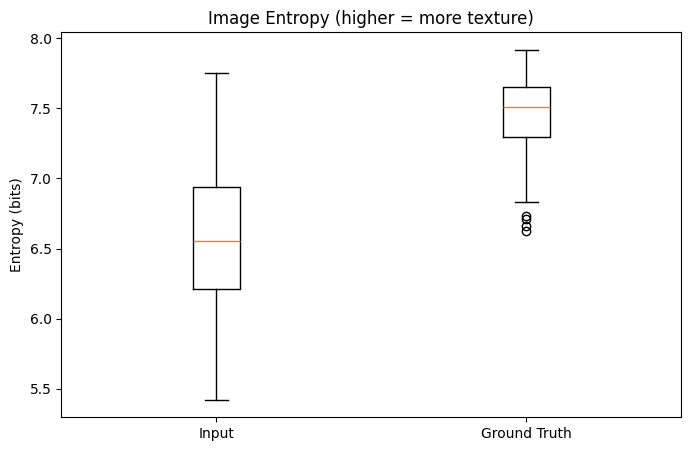

In [30]:
def image_entropy(img_gray):
    hist = cv2.calcHist([img_gray], [0], None, [256], [0,256])
    hist = hist / hist.sum()
    non_zero = hist[hist > 0]
    return -np.sum(non_zero * np.log2(non_zero))

def entropy_comparison(input_dir, gt_dir, num_samples=100):
    input_files = sorted(os.listdir(input_dir))
    gt_files = sorted(os.listdir(gt_dir))
    common = list(set(input_files) & set(gt_files))
    samples = random.sample(common, min(num_samples, len(common)))

    in_ent, gt_ent = [], []
    for f in samples:
        inp = cv2.imread(os.path.join(input_dir, f), cv2.IMREAD_GRAYSCALE)
        gt = cv2.imread(os.path.join(gt_dir, f), cv2.IMREAD_GRAYSCALE)
        if inp is None or gt is None:
            continue
        in_ent.append(image_entropy(inp))
        gt_ent.append(image_entropy(gt))

    plt.figure(figsize=(8,5))
    plt.boxplot([in_ent, gt_ent], labels=['Input', 'Ground Truth'])
    plt.title('Image Entropy (higher = more texture)')
    plt.ylabel('Entropy (bits)')
    plt.show()


entropy_comparison(input_dir, gt_dir, num_samples=100)


In [18]:
input_dir = os.path.join(DATASET_PATH, SPLIT, "input")
gt_dir = os.path.join(DATASET_PATH, SPLIT, "GT")